### Refinements to make for STAR-PULSE

- Split dataset and due to size split a few times
- Implement a library to see the cpu and gpu usage
- Try get an 80% accuracy or more
- try some more hyperparameter tunings
- do a 70/30 split
- split whole dataset in half so that can be used for demonstration purposes and the rest can be for test train
- If implementing voting system, decide why that over others and are they predictive or classifiers as they would need to be in the same category
- Note every step of code 

In [72]:
# Import the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

In [73]:
def check_resources():
    print(f"CPU: {psutil.cpu_percent()}% | RAM: {psutil.virtual_memory().percent}%")

print(check_resources())

CPU: 6.8% | RAM: 90.4%
None


In [74]:
# Load the dataset and split dataset
file_path = "telemetry.xlsx"
print(f"Loading dataset: {file_path}")
df = pd.read_excel(file_path)

# Parse Datetime and sort
df['Datetime'] = pd.to_datetime(df['UTC_Timestamp'], format='%H:%M:%S - %d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Datetime']).sort_values('Datetime').reset_index(drop=True)

# --- Data Exploration Information ---
print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns)
print(df.head())

print("Time range:", df['Datetime'].min(), "to", df['Datetime'].max())
print("Index range:", df.index.min(), "to", df.index.max())

print("\nMissing values per column:\n", df.isna().sum())

print("\nDataset Summary Statistics:")
print(df.describe())

Loading dataset: telemetry.xlsx
Dataset shape: (75994, 97)
Dataset columns: Index(['UTC_Timestamp', 'x_ecef', 'y_ecef', 'z_ecef', 'x_eci', 'y_eci',
       'z_eci', 'longitude', 'latitude', 'altitude', 'vx_eci', 'vy_eci',
       'vz_eci', 'hora', 'minuto', 'segundo', 'dia', 'mes', 'year',
       'ADM_status', 'EPS_status', 'HEATER_status', 'ADCS_status',
       'PAYLOAD_status', 'ADM_resetS', 'EPS_resetS', 'ADCS_resetS',
       'ADCS_resetH', 'COMMS_resetH', 'CDHS_reset', 'EPS_temperature',
       'state_charge', 'battery_voltage', 'average_current',
       'remaining_capacity', 'average_power', 'state_health', 'CH1_voltage',
       'CH1_current', 'CH2_voltage', 'CH2_current', 'CH3_voltage',
       'CH3_current', 'ADCS_current', 'COMMS_current', 'PAYLOAD_current',
       'HEATER_current', 'fault_flags', 'communication_flags',
       'transmission_flags_EPS', 'gyro_X', 'gyro_Y', 'gyro_Z', 'mag_X',
       'mag_Y', 'mag_Z', 'ADC1_CH1', 'ADC1_CH2', 'ADC1_CH3', 'ADC1_CH4',
       'ADC1_CH5',

In [75]:
#Feature selection

selected_features = [
    "battery_voltage",
    "average_current",
    "average_power",
    "remaining_capacity",
    "gyro_X",
    "gyro_Y",
    "gyro_Z",
    "EPS_temperature",
    "ADCS_temperature1",
    "BNO055_temperature"
]

sf = df[selected_features].copy()

print("\nselected features:")
print(selected_features)
print(sf.describe())

# Feature dictionary
feature_dict = {
    "altitude": "Altitude (m)",
    "latitude": "Latitude (°)",
    "longitude": "Longitude (°)",
    "battery_voltage": "Battery Voltage (V)",
    "average_current": "Average Current (mA)",
    "average_power": "Average Power (W)",
    "remaining_capacity": "Remaining Capacity (mAh)",
    "gyro_X": "Gyroscope X (°/s)",
    "gyro_Y": "Gyroscope Y (°/s)",
    "gyro_Z": "Gyroscope Z (°/s)",
    "EPS_temperature": "EPS Temperature (°C)",
    "ADCS_temperature1": "ADCS Temperature 1 (°C)",
    "BNO055_temperature": "BNO055 Temperature (°C)"
}

for col in selected_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')





selected features:
['battery_voltage', 'average_current', 'average_power', 'remaining_capacity', 'gyro_X', 'gyro_Y', 'gyro_Z', 'EPS_temperature', 'ADCS_temperature1', 'BNO055_temperature']
       battery_voltage  average_current  average_power  remaining_capacity  \
count     75994.000000     75994.000000   75994.000000        75994.000000   
mean         12.631854       135.611008     139.912167         1056.066809   
std          45.215455       869.203519     743.596152          653.020095   
min           2.500000     -2500.000000      -8.500000            0.000000   
25%           4.170000      -102.640000      -0.431022          980.450000   
50%           4.210000        90.420000       0.378050         1075.270000   
75%           4.260000       211.390000       0.893210         1125.120000   
max         253.000000      4093.000000    4093.000000         4093.000000   

             gyro_X        gyro_Y        gyro_Z  EPS_temperature  \
count  75994.000000  75994.000000  7599

In [76]:
# Chronological Train/Test split (70/30) Improved by preventing data leakage
split_point = int(len(df) * 0.70)

train_df = df.iloc[:split_point].copy()
test_df = df.iloc[split_point:].copy()

print(f"\nFinal Chronological Split Breakdown:")
print(f"- Training (First 70%): {len(train_df)} rows")
print(f"- Testing (Last 30%): {len(test_df)} rows")

# Impute missing values using train-based statistics to prevent data leakage
train_means = train_df[selected_features].mean()
train_df[selected_features] = train_df[selected_features].fillna(train_means)
test_df[selected_features] = test_df[selected_features].fillna(train_means)

def check_resources():
    print(f"CPU: {psutil.cpu_percent()}% | RAM: {psutil.virtual_memory().percent}%")
check_resources()

# Global Contamination Rate
CONTAMINATION_GLOBAL = 0.02
CONTAMINATION_FEATURE = 0.005



Final Chronological Split Breakdown:
- Training (First 70%): 53195 rows
- Testing (Last 30%): 22799 rows
CPU: 6.1% | RAM: 89.7%


In [97]:
# Model 1: Global Model: 3 Multivariate models & Voting (Runs through each timestamp and checks for anomalies along it which is great to see any anomalies between the timestamps)

print("\n--- Training Global Section: IF, LOF, and OCSVM ---")

scaler1 = StandardScaler()
X_train_scaled1 = scaler1.fit_transform(train_df[selected_features])
X_test_scaled1 = scaler1.transform(test_df[selected_features])

# 4a. Global Isolation Forest
global_if = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
global_if.fit(X_train_scaled1)
test_df['Vote_Global_IF'] = (global_if.predict(X_test_scaled1) == -1).astype(int)

# We keep the IF anomaly score to draw the timeline plot later
test_df['Global_IF_Anomaly_Score'] = global_if.decision_function(X_test_scaled1)

# 4b. Global Local Outlier Factor (RELAXED: n_neighbors=100)
global_lof = LocalOutlierFactor(n_neighbors=250, contamination=0.005, novelty=True)
global_lof.fit(X_train_scaled1)
test_df['Vote_Global_LOF'] = (global_lof.predict(X_test_scaled1) == -1).astype(int)

# 4c. Global One-Class SVM (RELAXED: gamma='auto')
global_svm = OneClassSVM(nu=0.01, kernel="rbf", gamma=0.001)
global_svm.fit(X_train_scaled1)
test_df['Vote_Global_SVM'] = (global_svm.predict(X_test_scaled1) == -1).astype(int)

# 4d. Global Committee Voting
print("The Global Committee is voting...")
test_df['Global_Vote_Sum'] = test_df['Vote_Global_IF'] + test_df['Vote_Global_LOF'] + test_df['Vote_Global_SVM']
# Threshold of 3 means ANY THREE models must agree to trigger the global alarm
test_df['Global_Prediction'] = np.where(test_df['Global_Vote_Sum'] >= 3, -1, 1)


--- Training Global Section: IF, LOF, and OCSVM ---
The Global Committee is voting...


In [98]:
# Model 2: Feature specific model: 3 Models per Feature & Voting (Where it runs through each feature and checks for anomalies along it which is great to see any anomalies in the features)

print("\n--- Training Feature-Specific Section: IF, LOF, OCSVM per feature ---")

m2_votes = np.zeros(len(test_df))
m2_triggered_lists = [[] for _ in range(len(test_df))]

for feature in selected_features:
    # Build temporal features
    temp_df = pd.DataFrame()
    temp_df['raw'] = df[feature]
    temp_df['diff'] = df[feature].diff().fillna(0)

    temp_df['roll_mean'] = df[feature].shift(1).rolling(window=10, min_periods=3).mean()
    temp_df['roll_std'] = df[feature].shift(1).rolling(window=10, min_periods=3).std().fillna(0)

    short_roll = df[feature].shift(1).rolling(window=10, min_periods=3).mean()
    long_roll = df[feature].shift(1).rolling(window=50, min_periods=10).mean()
    temp_df['drift'] = short_roll - long_roll
    
    # Split temporal dataset
    temp_train = temp_df.iloc[:split_point].copy()
    temp_test = temp_df.iloc[split_point:].copy()

    temp_train_means = temp_train.mean()
    temp_train = temp_train.fillna(temp_train_means)
    temp_test = temp_test.fillna(temp_train_means)
    
    temp_scaler = StandardScaler()
    temp_train_scaled = temp_scaler.fit_transform(temp_train)
    temp_test_scaled = temp_scaler.transform(temp_test)
    
    # Feature IF
    f_if = IsolationForest(n_estimators=50, contamination=0.005, random_state=42)
    f_if.fit(temp_train_scaled)
    vote_f_if = (f_if.predict(temp_test_scaled) == -1).astype(int)
    
    # Feature LOF (RELAXED: n_neighbors=100)
    f_lof = LocalOutlierFactor(n_neighbors=150, contamination=0.002, novelty=True)
    f_lof.fit(temp_train_scaled)
    vote_f_lof = (f_lof.predict(temp_test_scaled) == -1).astype(int)
    
    # Feature SVM (RELAXED: gamma='auto')
    f_svm = OneClassSVM(nu=0.005, kernel="rbf", gamma='auto')
    f_svm.fit(temp_train_scaled)
    vote_f_svm = (f_svm.predict(temp_test_scaled) == -1).astype(int)
    
    # Feature Committee Voting (Must have >= 2 models agree for this specific feature)
    feature_vote_sum = vote_f_if + vote_f_lof + vote_f_svm
    feature_consensus = feature_vote_sum >= 2
    
    for i, is_anom in enumerate(feature_consensus):
        if is_anom:
            m2_votes[i] += 1
            m2_triggered_lists[i].append(feature)

# Assign Feature-Specific results to test dataframe
test_df['Feature_Vote_Count'] = m2_votes
test_df['Feature_Triggered_List'] = [", ".join(feats) for feats in m2_triggered_lists]

# STRICTER THRESHOLD: Require at least 2 distinct features to be anomalous at once
FEATURE_ANOMALY_THRESHOLD = 3
test_df['Feature_Prediction'] = np.where(test_df['Feature_Vote_Count'] >= FEATURE_ANOMALY_THRESHOLD, -1, 1)


--- Training Feature-Specific Section: IF, LOF, OCSVM per feature ---


In [99]:
# Combines the results of both models to create a final anomaly prediction. If either model flags an anomaly, the combined result is an anomaly.

# Combined anomaly = Model 1 anomaly OR Model 2 anomaly
test_df['Combined_Prediction'] = np.where(
    (test_df['Global_Prediction'] == -1) | (test_df['Feature_Prediction'] == -1), 
    -1, 1
)

In [103]:
# Label free performance diagnostics

print("\n=== Label-Free Performance Diagnostics ===")
print("Note: Because these models are unsupervised and we lack ground-truth ")
print("labels, these are distribution diagnostics, not traditional accuracy metrics.\n")

total_test = len(test_df)

# Global Breakdown
print("--- Global Committee Breakdown ---")
print(f"IF Global Flags:   {test_df['Vote_Global_IF'].sum()} ({(test_df['Vote_Global_IF'].sum()/total_test)*100:.2f}%)")
print(f"LOF Global Flags:  {test_df['Vote_Global_LOF'].sum()} ({(test_df['Vote_Global_LOF'].sum()/total_test)*100:.2f}%)")
print(f"SVM Global Flags:  {test_df['Vote_Global_SVM'].sum()} ({(test_df['Vote_Global_SVM'].sum()/total_test)*100:.2f}%)")

global_anomalies = (test_df['Global_Prediction'] == -1).sum()
feature_anomalies = (test_df['Feature_Prediction'] == -1).sum()
combined_anomalies = (test_df['Combined_Prediction'] == -1).sum()
agreements = (test_df['Global_Prediction'] == test_df['Feature_Prediction']).sum()

print("\n--- Final Consensus Breakdown ---")
print(f"Total Test Instances: {total_test}")
print(f"Global Consensus Flags (>=2 models):  {global_anomalies} ({global_anomalies/total_test*100:.2f}%)")
print(f"Feature Consensus Flags:              {feature_anomalies} ({feature_anomalies/total_test*100:.2f}%)")
print(f"Final Combined Flags (Global OR Feat):{combined_anomalies} ({combined_anomalies/total_test*100:.2f}%)")
print(f"Global/Feature Agreement Rate:        {agreements/total_test*100:.2f}%")

if_only = ((test_df['Vote_Global_IF'] == 1) & (test_df['Global_Prediction'] != -1)).sum()
lof_only = ((test_df['Vote_Global_LOF'] == 1) & (test_df['Global_Prediction'] != -1)).sum()
svm_only = ((test_df['Vote_Global_SVM'] == 1) & (test_df['Global_Prediction'] != -1)).sum()

print("\n--- Individual Model Flags Excluded by Global Voting ---")
print(f"IF-only flags excluded by voting:  {if_only}")
print(f"LOF-only flags excluded by voting: {lof_only}")
print(f"SVM-only flags excluded by voting: {svm_only}")


=== Label-Free Performance Diagnostics ===
Note: Because these models are unsupervised and we lack ground-truth 
labels, these are distribution diagnostics, not traditional accuracy metrics.

--- Global Committee Breakdown ---
IF Global Flags:   364 (1.60%)
LOF Global Flags:  320 (1.40%)
SVM Global Flags:  315 (1.38%)

--- Final Consensus Breakdown ---
Total Test Instances: 22799
Global Consensus Flags (>=2 models):  47 (0.21%)
Feature Consensus Flags:              4 (0.02%)
Final Combined Flags (Global OR Feat):51 (0.22%)
Global/Feature Agreement Rate:        99.78%

--- Individual Model Flags Excluded by Global Voting ---
IF-only flags excluded by voting:  317
LOF-only flags excluded by voting: 273
SVM-only flags excluded by voting: 268


In [101]:
# Human review: Flagged anomalies for manual inspection

# Organize columns for the final export
output_cols = ['Datetime'] + selected_features + [
    'Vote_Global_IF', 'Vote_Global_LOF', 'Vote_Global_SVM', 'Global_Vote_Sum', 'Global_Prediction',
    'Feature_Vote_Count', 'Feature_Triggered_List', 'Feature_Prediction', 
    'Combined_Prediction', 'Global_IF_Anomaly_Score'
]

export_df = test_df[output_cols].copy()

# Full test dataset
export_df.to_csv("test_anomalies_full.csv", index=False)
# Flagged-only dataset
flagged_df = export_df[export_df['Combined_Prediction'] == -1].copy()
flagged_df.to_csv("test_anomalies_flagged_only.csv", index=False)

print(f"\nExports Complete:")
print(f"- 'test_anomalies_full.csv' ({len(export_df)} rows)")
print(f"- 'test_anomalies_flagged_only.csv' ({len(flagged_df)} rows)")


Exports Complete:
- 'test_anomalies_full.csv' (22799 rows)
- 'test_anomalies_flagged_only.csv' (51 rows)



Generating visualisations. Close each plot to see the next one...


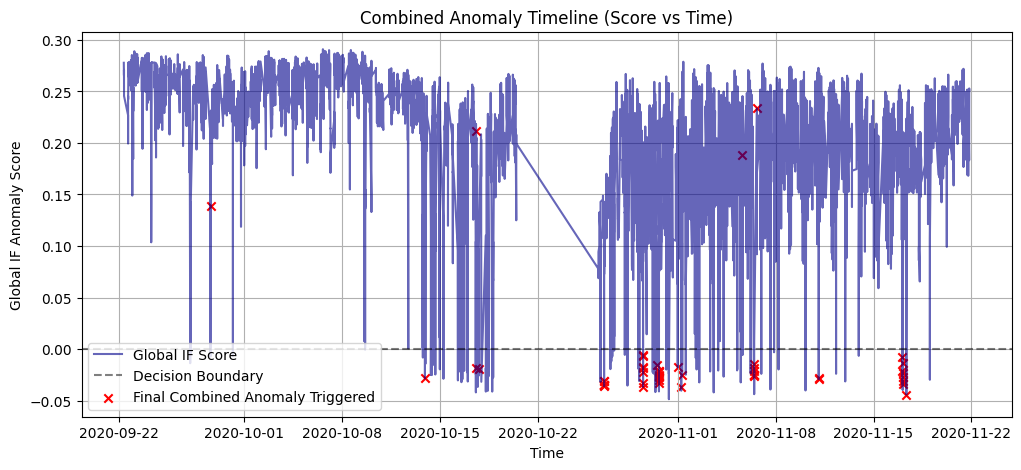

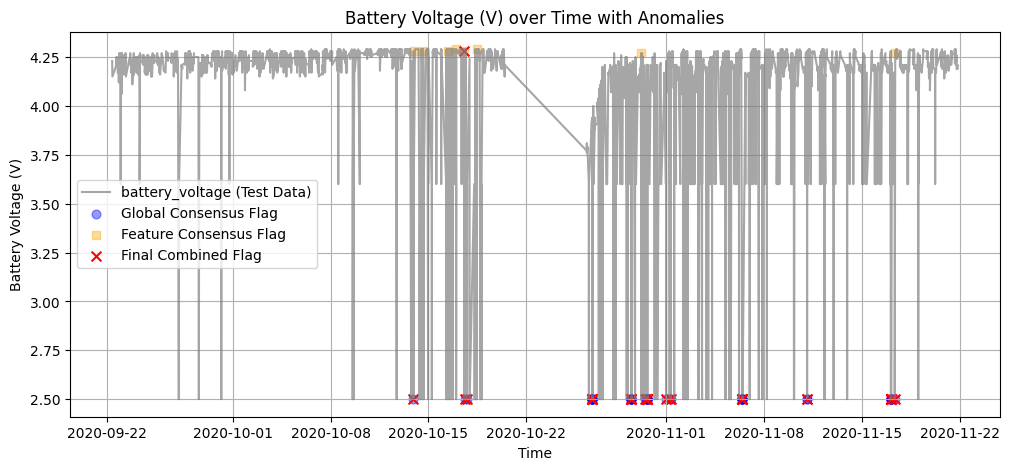

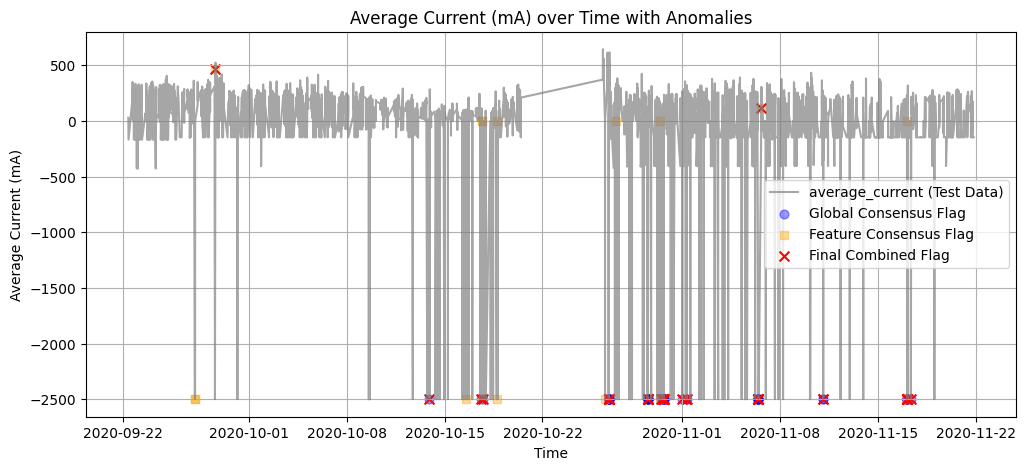

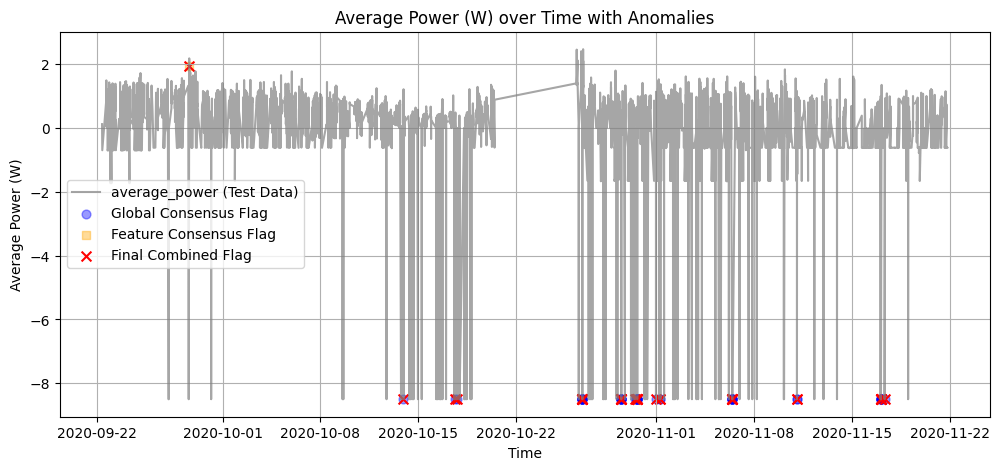

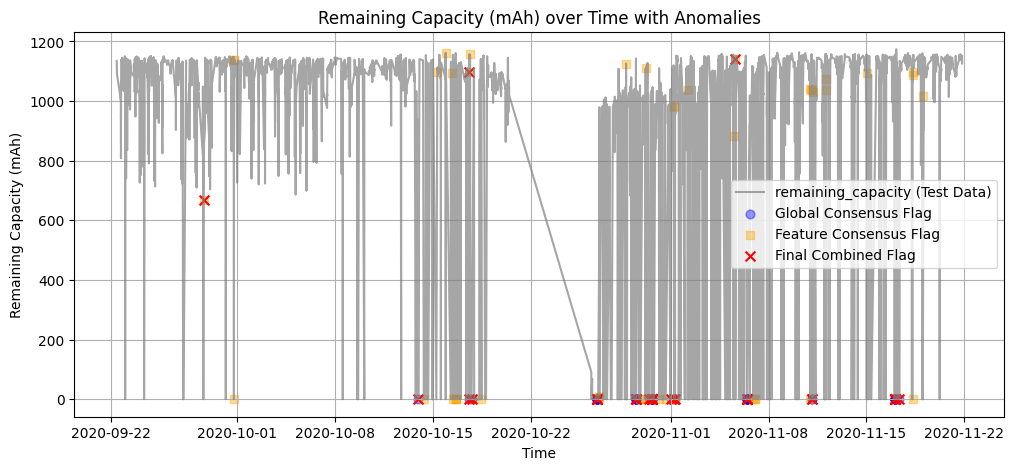

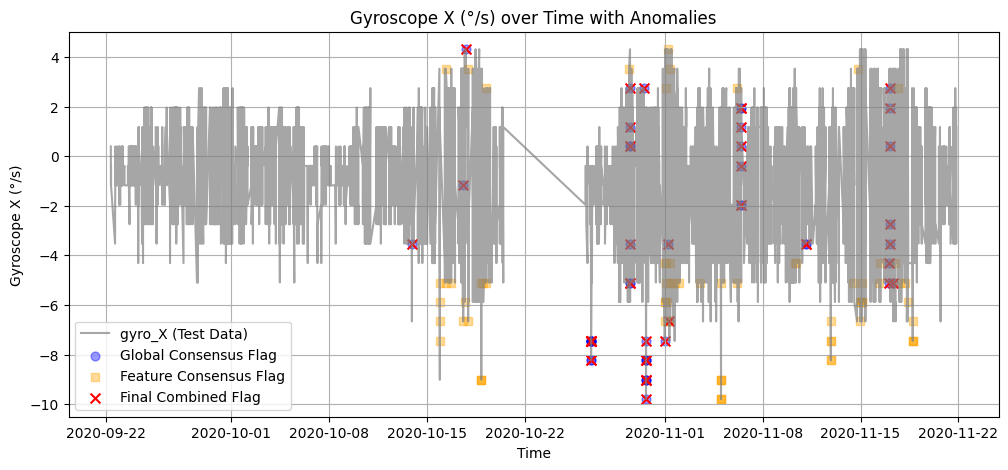

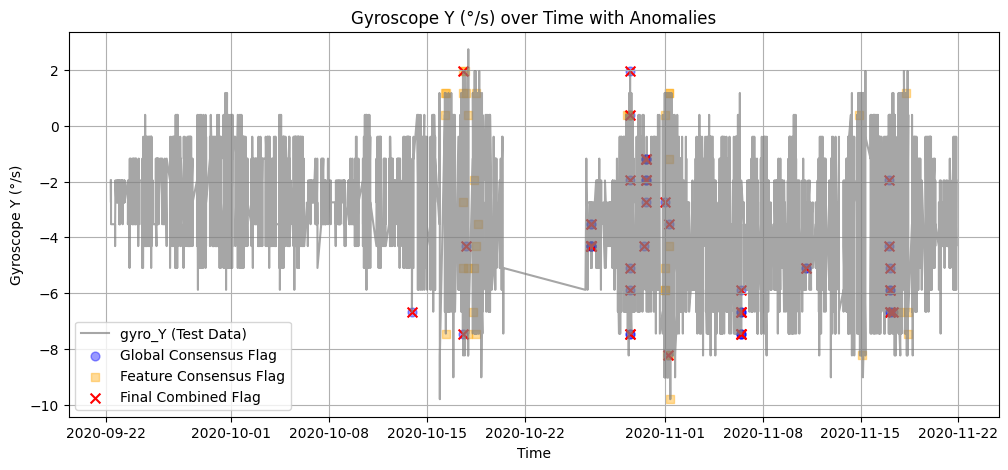

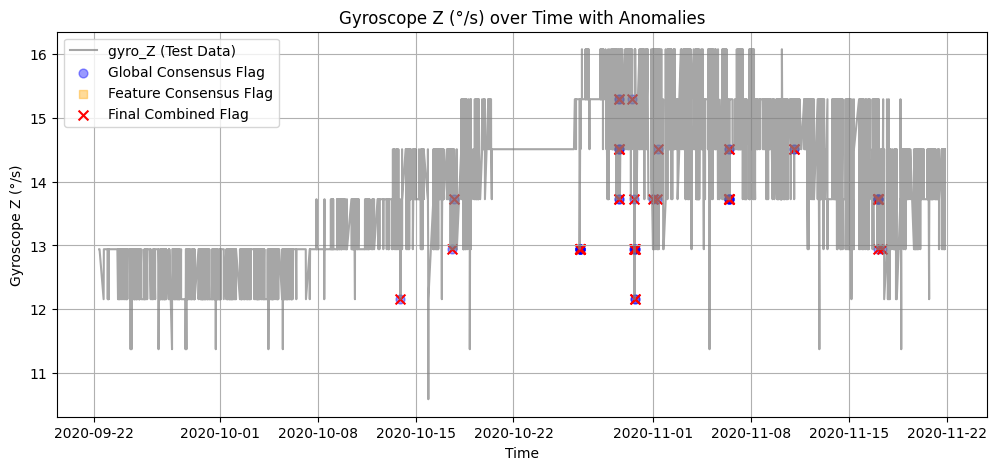

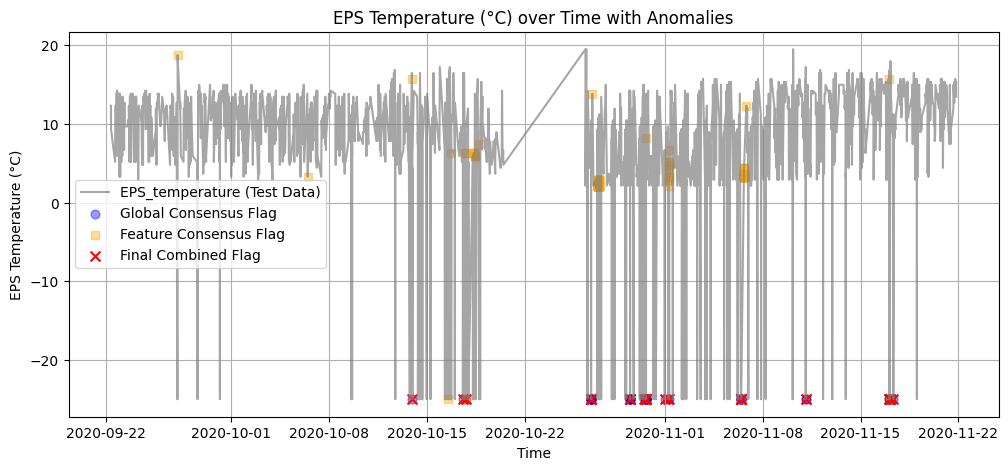

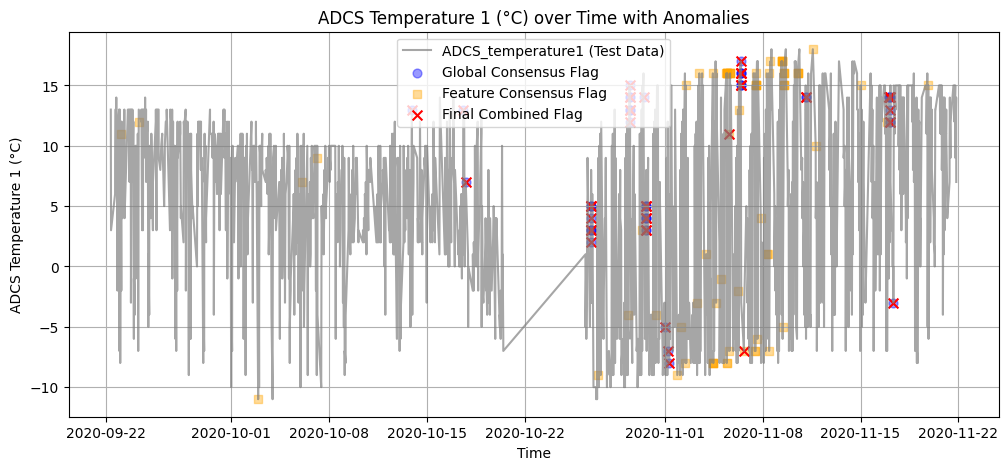

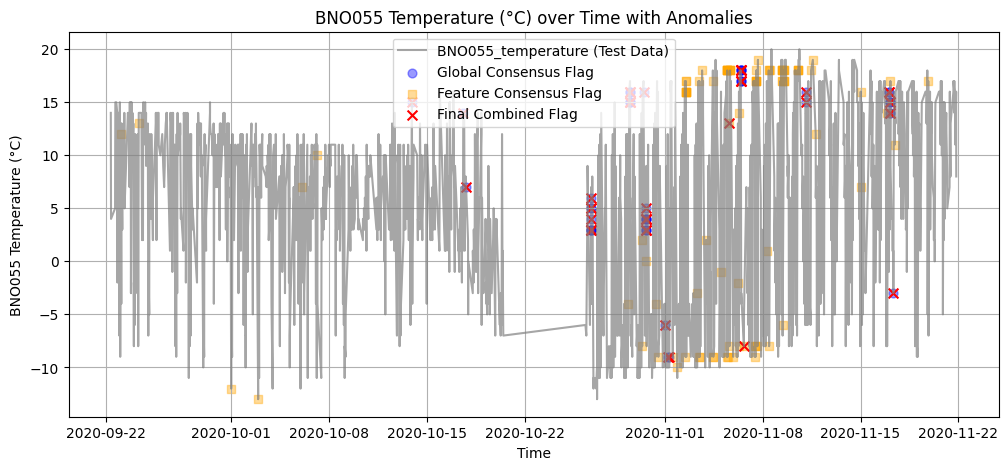

In [102]:
# Visualisations

print("\nGenerating visualisations. Close each plot to see the next one...")

# Plot 1: Combined Anomaly Timeline
plt.figure(figsize=(12, 5))
# Using IF Score as a baseline representation of the timeline
plt.plot(test_df['Datetime'], test_df['Global_IF_Anomaly_Score'], label='Global IF Score', color='darkblue', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Decision Boundary')

comb_points = test_df[test_df['Combined_Prediction'] == -1]
plt.scatter(comb_points['Datetime'], comb_points['Global_IF_Anomaly_Score'], color='red', label='Final Combined Anomaly Triggered', marker='x')

plt.title("Combined Anomaly Timeline (Score vs Time)")
plt.xlabel("Time")
plt.ylabel("Global IF Anomaly Score")
plt.legend()
plt.grid()
plt.show()

# Plot 2: Individual Feature Overlay
for feature in selected_features:
    plt.figure(figsize=(12, 5))
    
    # Base feature plot
    plt.plot(test_df['Datetime'], test_df[feature], label=f"{feature} (Test Data)", color='gray', alpha=0.7)
    
    # Extract anomaly points
    glob_points = test_df[test_df['Global_Prediction'] == -1]

    feat_points = test_df[
        test_df['Feature_Triggered_List'].str.contains(feature, na=False)
    ]

    comb_points = test_df[
        (test_df['Combined_Prediction'] == -1) &
        (
            (test_df['Global_Prediction'] == -1) |
            (test_df['Feature_Triggered_List'].str.contains(feature, na=False))
        )
    ]
    
    # Scatter overlays
    plt.scatter(glob_points['Datetime'], glob_points[feature], color='blue', label='Global Consensus Flag', marker='o', alpha=0.4, s=40)
    plt.scatter(feat_points['Datetime'], feat_points[feature], color='orange', label='Feature Consensus Flag', marker='s', alpha=0.4, s=40)
    plt.scatter(comb_points['Datetime'], comb_points[feature], color='red', label='Final Combined Flag', marker='x', s=50)
    
    plt.title(f"{feature_dict[feature]} over Time with Anomalies")
    plt.xlabel("Time")
    plt.ylabel(f"{feature_dict[feature]}")
    plt.legend()
    plt.grid()
    plt.show()